In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
housing_data = pd.read_csv("housing.csv")
#print(housing_data.shape)
print(housing_data.head())
#print(housing_data.describe())
#print(f"missing data values are: ",housing_data.isnull().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


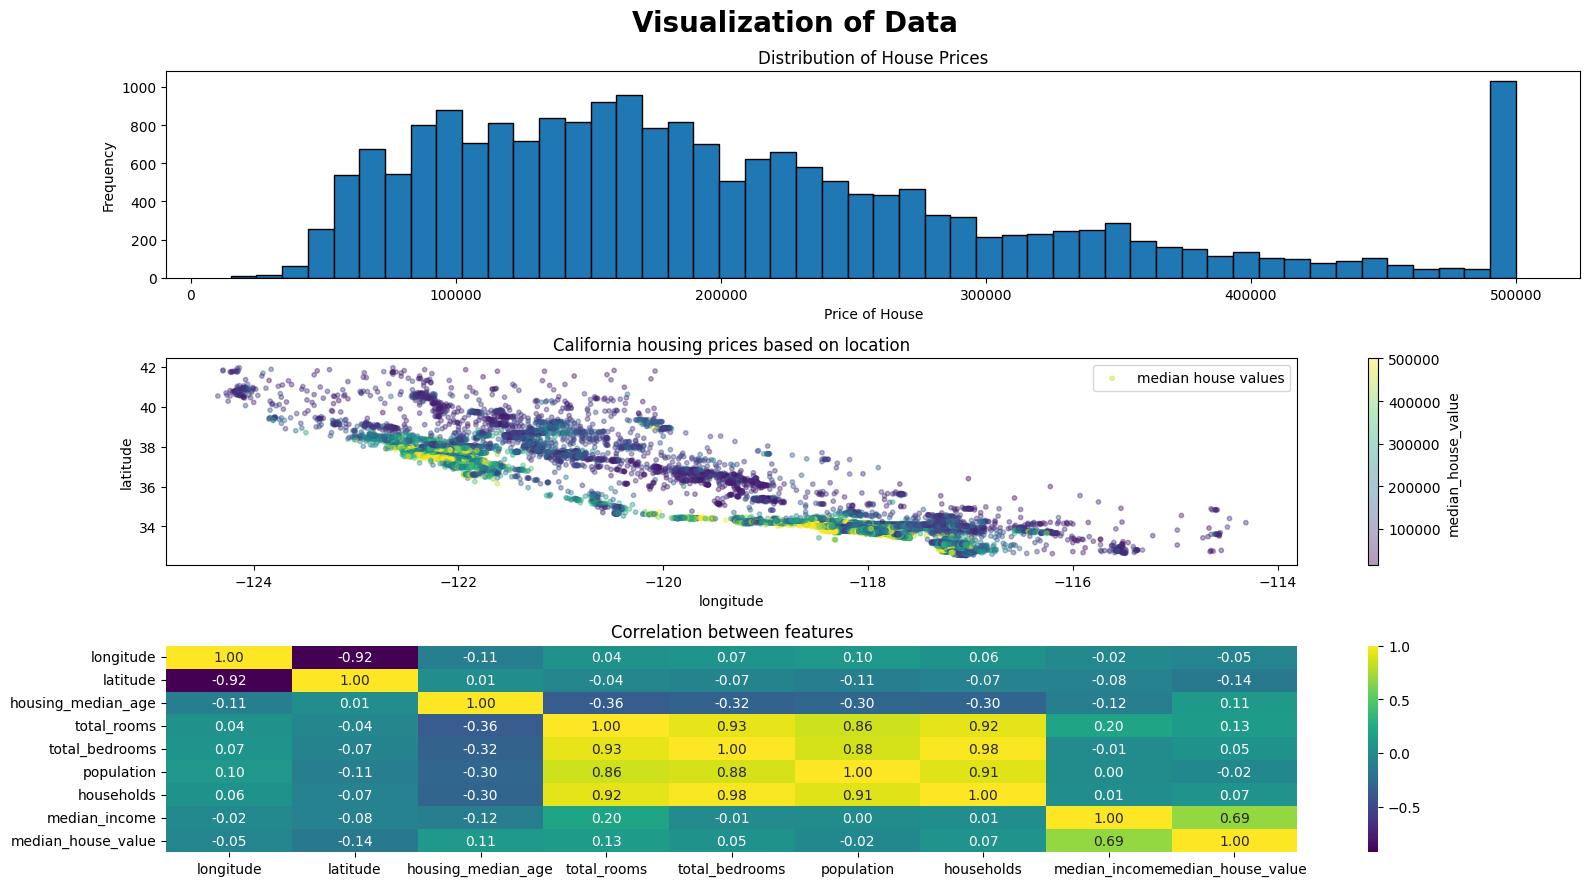

In [246]:
fig , axes = plt.subplots(3,1,figsize = (16,9))
fig.suptitle("Visualization of Data",fontsize = 20,fontweight = "bold")
#plot for median house values 
housing_data["median_house_value"].plot(kind = "hist",ax = axes[0],edgecolor = "black",bins = 50)
axes[0].set_xlabel("Price of House")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of House Prices",fontsize = 12)
#plot for longitude vs latitude and their diff in price
hmap = housing_data.plot(kind="scatter",x = "longitude",y = "latitude",c = "median_house_value",ax = axes[1],label = "median house values",alpha = 0.4,s=10)
axes[1].set_title("California housing prices based on location",fontsize = 12)
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("latitude")
#plot for correlation
correlation = housing_data.corr(numeric_only=True)
sns.heatmap(correlation,annot = True,fmt = '.2f',cmap = 'viridis',ax = axes[2])
axes[2].set_title("Correlation between features")
axes[2].tick_params(rotation = 0)
#correlations = housing_data.corr(numeric_only=True)['median_house_value']
#correlation_scored = correlations.abs().sort_values(ascending=False)
#print("top 8 correlations are:\n",correlation_scored.head(8))
plt.tight_layout()
plt.show()

In [247]:
#filling Na data 
housing_data['total_bedrooms'] = housing_data['total_bedrooms'].fillna(housing_data['total_bedrooms'].median())
print("Number of Nan columns in total bedrooms",housing_data['total_bedrooms'].isnull().sum())
print(housing_data['ocean_proximity'].value_counts())
print(housing_data.shape)
housing_data = pd.get_dummies(housing_data,columns = ['ocean_proximity'],drop_first = True) 
print(housing_data.shape)
new_cols = [col for col in housing_data.columns if 'ocean_proximity' in col]
print(new_cols)

Number of Nan columns in total bedrooms 0
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
(20640, 10)
(20640, 13)
['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [248]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
print(housing_data.columns)
train_X = housing_data.drop('median_house_value',axis = 1)
train_Y = housing_data.median_house_value
X_train,X_test,Y_train,Y_test = train_test_split(train_X,train_Y,train_size = 0.8,test_size = 0.2,random_state = 42)
print(f"lenght of train test split of X: {len(X_train)} and length of train test split of Y: {len(Y_train)}")
baseline_pred = np.full(len(Y_test),Y_train.mean())
baseline_mae = mean_absolute_error(Y_test,baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(Y_test, baseline_pred))
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"baseline always prediction is : {Y_train.mean():,.2f}")
print(f"baseline prediction was: {baseline_pred[0]:,.2f}")
print(f"baseline mean absolute error is : {baseline_mae:,.2f}")

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')
lenght of train test split of X: 16512 and length of train test split of Y: 16512
Baseline RMSE: $114,485.64
baseline always prediction is : 207,194.69
baseline prediction was: 207,194.69
baseline mean absolute error is : 90,606.85


In [249]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,Y_train)
prediction = model.predict(X_test)
prediction = pd.Series(prediction,index = Y_test.index)
after_mae = mean_absolute_error(Y_test,prediction)
after_rmae = np.sqrt(mean_squared_error(Y_test, prediction))
improvement = ((baseline_mae - after_mae) / baseline_mae) * 100
print(f"improvement in % is: {improvement:.1f}%")
print(f"after mae: {after_mae:.2f} and after rmae : {after_rmae:.2f}")
feature_importance = pd.DataFrame({"features" : X_train.columns,"coefficient" : model.coef_}).sort_values('coefficient',ascending = False)
print(f"top 5 features most important\n: {feature_importance.head()}")
print(f"top 5 least important features\n: {feature_importance.tail()}")

improvement in % is: 44.1%
after mae: 50670.74 and after rmae : 70060.52
top 5 features most important
:                       features    coefficient
9       ocean_proximity_ISLAND  136125.072615
7                median_income   39473.975175
11  ocean_proximity_NEAR OCEAN    3431.140073
2           housing_median_age    1102.185084
4               total_bedrooms     102.789395
top 5 least important features
:                     features   coefficient
5                 population    -38.172906
10  ocean_proximity_NEAR BAY  -5136.642217
1                   latitude -25468.352050
0                  longitude -26838.273372
8     ocean_proximity_INLAND -39786.656161


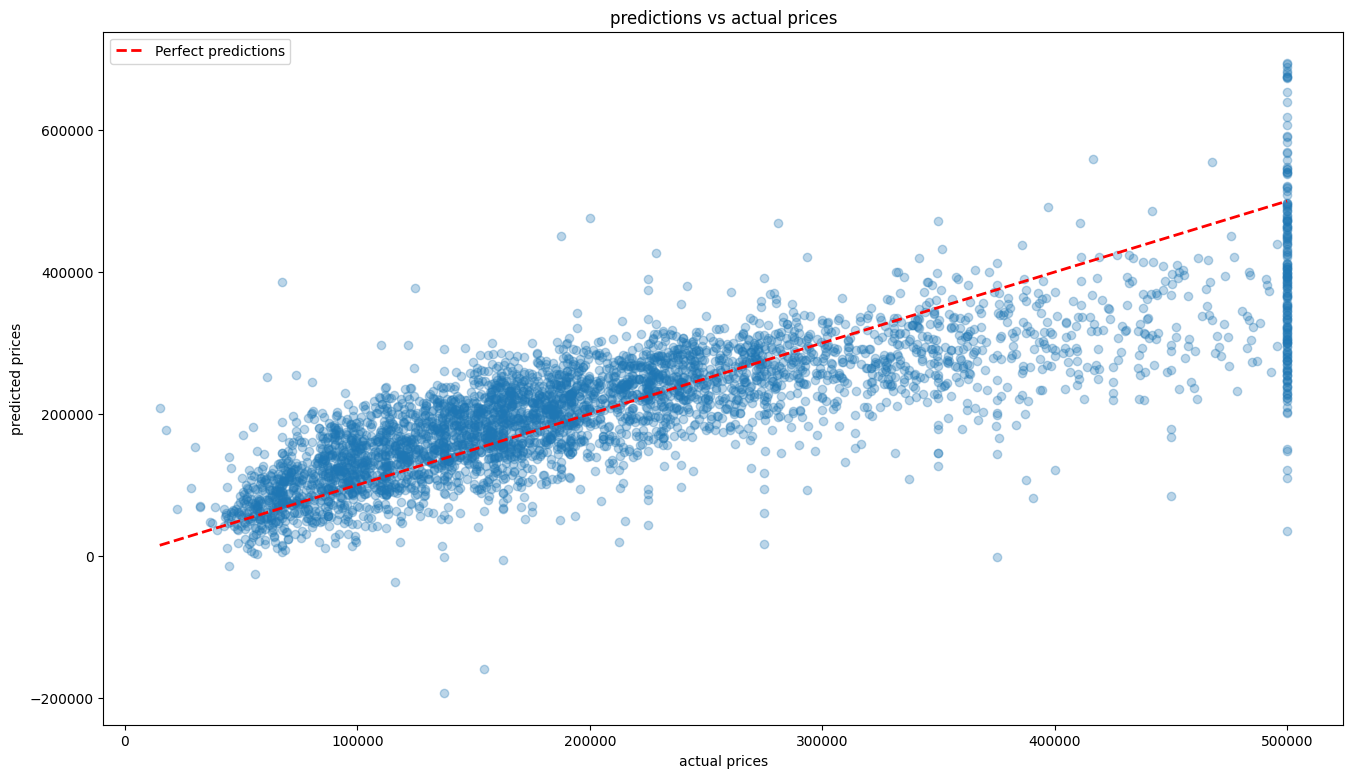

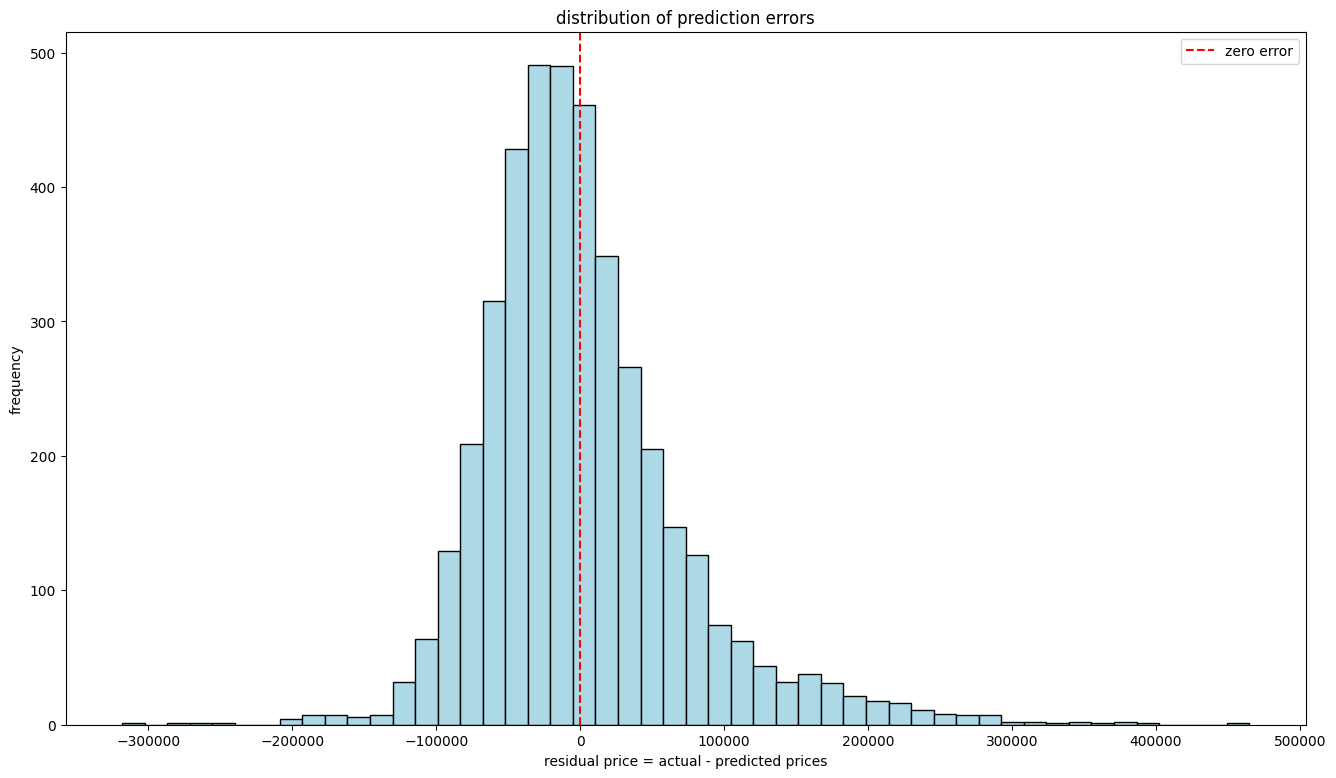

10 worst predictions: 
         actual      predicted          error
6688   500001.0   35183.231190  464817.768810
10574  500001.0  110062.790691  389938.209309
459    500001.0  120449.927243  379551.072757
18346  375000.0   -1327.534868  376327.534868
19542  450000.0   84492.967914  365507.032086
12389  500001.0  148035.201499  351965.798501
12069  500001.0  151060.353362  348940.646638
13890  137500.0 -193444.917209  330944.917209
4548    67500.0  385733.770080  318233.770080
9172   154600.0 -159095.902287  313695.902287

 worst features
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
6688     -118.08     34.15                28.0        238.0            58.0   
10574    -117.70     33.72                 6.0        211.0            51.0   
459      -122.25     37.87                52.0        609.0           236.0   
18346    -122.15     37.43                20.0      11709.0           435.0   
19542    -120.92     37.63                39.0         45.0

In [250]:
plt.figure(figsize = (16,9))
plt.scatter(Y_test,prediction,alpha=0.3)
plt.plot([Y_test.min(),Y_test.max()],[Y_test.min(),Y_test.max()],'r--',lw=2,label = 'Perfect predictions')
plt.xlabel('actual prices')
plt.ylabel('predicted prices')
plt.title('predictions vs actual prices')
plt.legend()
plt.show()

plt.figure(figsize = (16,9))
residuals = Y_test - prediction
plt.hist(residuals,bins = 50,edgecolor = 'black',color = 'lightblue')
plt.xlabel('residual price = actual - predicted prices')
plt.ylabel('frequency')
plt.title('distribution of prediction errors')
plt.axvline(x = 0,color = 'r',linestyle = '--',label = 'zero error')
plt.legend()
plt.show()

errors = np.abs(residuals)
worst_indice = errors.nlargest(10).index

print("10 worst predictions: ")
worst_predictions = pd.DataFrame({
        'actual' : Y_test.loc[worst_indice],
        'predicted' : prediction.loc[worst_indice],
        'error' : errors.loc[worst_indice]
})
print(worst_predictions)
print('\n worst features')
print(X_test.loc[worst_indices])

In [334]:
# reimporting and feature engineering features
housing_data = pd.read_csv('housing.csv')
housing_data['total_bedrooms'] = housing_data['total_bedrooms'].fillna(housing_data['total_bedrooms'].median())
housing_data['rooms_per_household'] = housing_data['total_rooms'] / housing_data['households']
housing_data['bedrooms_per_room'] = housing_data['total_bedrooms'] /  housing_data['total_rooms']
housing_data['population_per_household'] = housing_data['population'] / housing_data['households']

#housing_data = housing_data.drop(['total_rooms','households','total_bedrooms','population'],axis = 1)

housing_data = pd.get_dummies(housing_data,drop_first = True)
print("the shape after creating new features: \n",housing_data.columns.tolist())
#new_cols = [col for col in housing_data if 'ocean_proximity' in col]
#print(new_cols)
#housing_data.head()

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge

# selecting 

train_X = housing_data.drop('median_house_value',axis = 1)
train_Y = housing_data.median_house_value

# splitting dataset 
X_train,X_test,Y_train,Y_test = train_test_split(train_X,train_Y,test_size = 0.2,random_state = 42)
# defining fitting predicting model 
model = LinearRegression().fit(X_train,Y_train)
prediction = model.predict(X_test)
# givving that only positive numbers are used
prediction_max = np.maximum(prediction,0) 

new_mae = mean_absolute_error(Y_test,prediction_max)
new_rmae = np.sqrt(mean_squared_error(Y_test,prediction_max))
print("The new mae is: ",new_mae)
print("The new rmae is: ",new_rmae)

print(f"Comparison between old and new mae and rmae: the old mae is {after_mae:.2f} and the new mae is {new_mae:.2f} and the old rmae is {after_rmae:.2f} and new rmae is {new_rmae:.2f}")
improvement = (after_mae - new_mae) / after_mae * 100
print("improvement is ",improvement)


the shape after creating new features: 
 ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
The new mae is:  50765.337374526
The new rmae is:  72300.7803427921
Comparison between old and new mae and rmae: the old mae is 50670.74 and the new mae is 50765.34 and the old rmae is 70060.52 and new rmae is 72300.78
improvement is  -0.18669381350645398


In [319]:
# the most important features of Line regressing model
feature_importance = pd.DataFrame({'feature' : X_train.columns , 'coef' : model.coef_}).sort_values('coef',key = abs ,ascending = False)
print('top 10 most important features:',feature_importance.head(10))

top 10 most important features:                        feature           coef
5            bedrooms_per_room  337095.066160
8       ocean_proximity_ISLAND  139550.011123
3                median_income   42913.244898
7       ocean_proximity_INLAND  -35630.788858
0                    longitude  -26760.667878
1                     latitude  -24605.649350
10  ocean_proximity_NEAR OCEAN    8497.479106
4          rooms_per_household    3412.873504
9     ocean_proximity_NEAR BAY    3098.274290
2           housing_median_age     890.051452


In [335]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
#ridge 
model = Ridge(alpha = 1.0).fit(X_train,Y_train)
prediction = model.predict(X_test)
prediction = np.maximum(prediction,0)
ridge_mae = mean_absolute_error(Y_test,prediction)
ridge_rmae = np.sqrt(mean_squared_error(Y_test,prediction))
print(f"Comparison between old and new mae and rmae: the old mae is {after_mae:.2f} and the new mae is {ridge_mae:.2f} and the old rmae is {after_rmae:.2f} and new rmae is {ridge_rmae:.2f}")

Comparison between old and new mae and rmae: the old mae is 50670.74 and the new mae is 50727.49 and the old rmae is 70060.52 and new rmae is 72048.07


In [336]:
# creating fitting  predicting and comparing with the prediction and actual [rice
model = XGBRegressor(n_estimators = 300,learning_rate = 0.1,random_state = 42).fit(X_train,Y_train)
prediction_xgb = model.predict(X_test)
prediction_xgb = np.maximum(prediction_xgb,0)
xgb_mae = mean_absolute_error(Y_test,prediction_xgb)
xgb_rmae = np.sqrt(mean_squared_error(Y_test,prediction_xgb))
print(f"Comparison between old and new mae and rmae: the old mae is {after_mae:.2f} and the new mae is {xgb_mae:.2f} and the old rmae is {after_rmae:.2f} and new rmae is {xgb_rmae:.2f}")

Comparison between old and new mae and rmae: the old mae is 50670.74 and the new mae is 29562.71 and the old rmae is 70060.52 and new rmae is 45683.47


In [360]:
# the best model

results = pd.DataFrame({'Model': ['Linear Regression','Ridge','XGBoost'],'MAE' : [after_mae,ridge_mae,xgb_mae],'RMAE' : [after_rmae,ridge_rmae,xgb_rmae]})
results['improvement vs baseline %'] = (results['MAE'].iloc[0] - results['MAE']) / results['MAE'].iloc[0] * 100
results = results.sort_values('MAE')
print(results)

winner = results.iloc[0]
print(f"Model: {winner['Model']}")
print(f"MAE: {winner['MAE']}")
print(f"RMAE: {winner['RMAE']}")
print(f"improvement vs baseline % is: {winner['improvement vs baseline %']:.1f}")

# the most important features used by the xgb model
feature_importance_xgb = pd.DataFrame ({'feature' : X_train.columns,
                                    'importance': model.feature_importances_})
print("top 10 most important features in xgb: \n",feature_importance_xgb.head(10))

               Model           MAE          RMAE  improvement vs baseline %
2            XGBoost  29562.714720  45683.469054                  41.657225
0  Linear Regression  50670.738241  70060.521845                   0.000000
1              Ridge  50727.485650  72048.074343                  -0.111992
Model: XGBoost
MAE: 29562.714720260265
RMAE: 45683.46905405653
improvement vs baseline % is: 41.7
top 10 most important features in xgb: 
                feature  importance
0            longitude    0.023399
1             latitude    0.024655
2   housing_median_age    0.023158
3          total_rooms    0.007376
4       total_bedrooms    0.009375
5           population    0.007432
6           households    0.009454
7        median_income    0.243156
8  rooms_per_household    0.011099
9    bedrooms_per_room    0.010162
